In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
import os

plt.style.use('seaborn-v0_8-whitegrid')

In [91]:
# Load Data
df = pd.read_csv("data/TMDB_all_movies.csv")
print(f"Original dataset: {df.shape[0]:,} movies")
print(f"\nColumns: {df.columns.tolist()}")

Original dataset: 1,137,484 movies

Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography', 'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path']


## Data Cleaning
- Remove NA values in critical columns
- Remove duplicates
- Filter realistic budget values
- Remove outliers using IQR method

In [ ]:
# Remove NA values in critical columns 
print(f"Before: {len(df):,} rows")

# ALL critical columns must be present
critical_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']
df = df.dropna(subset=critical_cols)

# Remove rows with zero values in critical numeric columns
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]  # Films with actual revenue data are more reliable
df = df[df['runtime'] > 0]
df = df[df['vote_count'] > 0]

# Fill text columns with empty string
text_cols = ['genres', 'overview', 'cast', 'director', 'title']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna('')

print(f"After NA/zero removal: {len(df):,} rows")

=== REMOVING NA VALUES (STRICT) ===
Before: 1,137,484 rows
After NA/zero removal: 13,077 rows
After NA/zero removal: 13,077 rows


In [ ]:
# Remove Duplicates
print("=== REMOVING DUPLICATES ===")
print(f"Before: {len(df):,} rows")

# Remove duplicates based on title and release year 
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year

duplicates_before = df.duplicated(subset=['title'], keep='first').sum()
df = df.drop_duplicates(subset=['title'], keep='first')

print(f"After duplicate removal: {len(df):,} rows")
print(f"Removed: {duplicates_before:,} duplicate movies")

=== REMOVING DUPLICATES ===
Before: 13,077 rows
After duplicate removal: 12,645 rows
Removed: 432 duplicate movies


In [ ]:
# Filter Realistic Budget Values 
print(f"Before: {len(df):,} rows")

# More strict filters:
# - Minimum budget: $1M (exclude low-budget films - harder to predict)
# - Maximum budget: $400M (exclude extreme outliers)
df = df[(df['budget'] >= 1_000_000) & (df['budget'] <= 400_000_000)]

# Revenue should be reasonable too (data quality indicator)
df = df[(df['revenue'] >= 100_000) & (df['revenue'] <= 3_000_000_000)]

# Stricter runtime filter (typical theatrical releases)
df = df[(df['runtime'] >= 60) & (df['runtime'] <= 240)]

# Minimum vote count for reliable data (films with more reviews = better data)
df = df[df['vote_count'] >= 10]

# Vote average should be reasonable
df = df[(df['vote_average'] >= 1) & (df['vote_average'] <= 10)]

print(f"After budget/runtime/vote filter: {len(df):,} rows")
print(f"\nBudget statistics:")
print(df['budget'].describe())

=== FILTERING REALISTIC BUDGETS (STRICT) ===
Before: 12,645 rows
After budget/runtime/vote filter: 9,303 rows

Budget statistics:
count    9.303000e+03
mean     2.735668e+07
std      3.888517e+07
min      1.000000e+06
25%      5.000000e+06
50%      1.350000e+07
75%      3.003475e+07
max      4.000000e+08
Name: budget, dtype: float64


=== REMOVING OUTLIERS (STRICT IQR Method) ===
Before: 9,303 rows
   budget: removed 971 outliers
   runtime: removed 325 outliers
   vote_count: removed 755 outliers
   popularity: removed 294 outliers
   revenue: removed 638 outliers

After outlier removal: 6,320 rows
   revenue: removed 638 outliers

After outlier removal: 6,320 rows


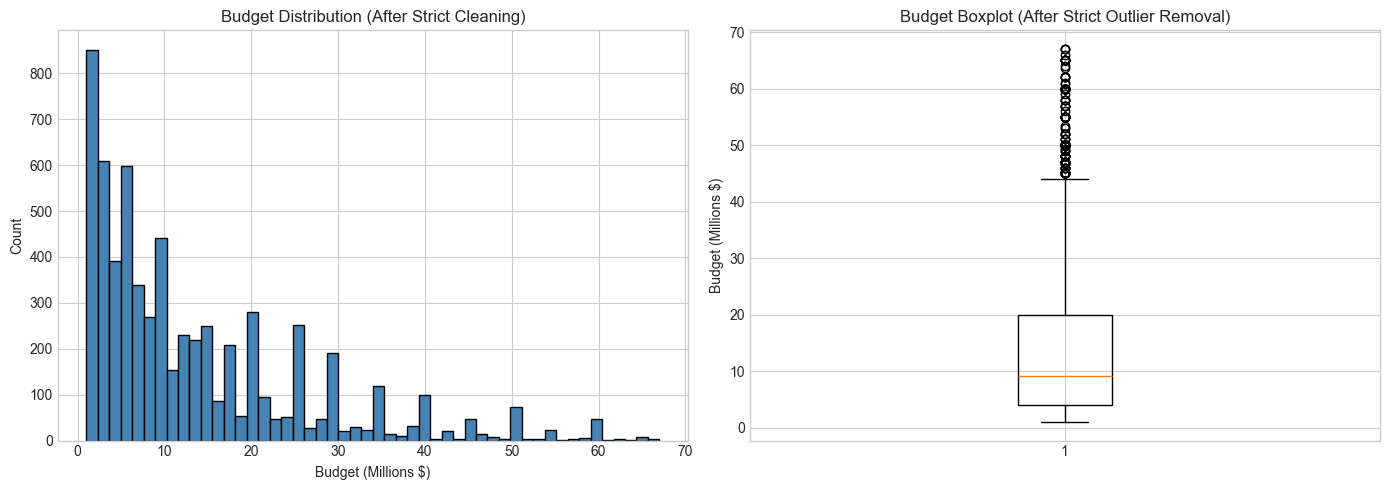


✅ Final cleaned dataset: 6,320 movies

📊 Budget range: $1.0M - $67.0M


In [ ]:
# Remove Outliers using IQR method 
print(f"Before: {len(df):,} rows")

def remove_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    before = len(df)
    df_clean = df[(df[column] >= lower) & (df[column] <= upper)]
    print(f"   {column}: removed {before - len(df_clean):,} outliers")
    return df_clean

# Use stricter multiplier (1.5 instead of 3.0)
df = remove_outliers_iqr(df, 'budget', multiplier=1.5)
df = remove_outliers_iqr(df, 'runtime', multiplier=1.5)
df = remove_outliers_iqr(df, 'vote_count', multiplier=1.5)
df = remove_outliers_iqr(df, 'popularity', multiplier=1.5)

# Also remove revenue outliers
df = remove_outliers_iqr(df, 'revenue', multiplier=1.5)

print(f"\nAfter outlier removal: {len(df):,} rows")

# Visualize budget distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['budget'] / 1e6, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Budget (Millions $)')
axes[0].set_ylabel('Count')
axes[0].set_title('Budget Distribution (After Strict Cleaning)')

axes[1].boxplot(df['budget'] / 1e6)
axes[1].set_ylabel('Budget (Millions $)')
axes[1].set_title('Budget Boxplot (After Strict Outlier Removal)')

plt.tight_layout()
plt.show()

print(f"\n Final cleaned dataset: {len(df):,} movies")
print(f"\n Budget range: ${df['budget'].min()/1e6:.1f}M - ${df['budget'].max()/1e6:.1f}M")

## Feature Engineering
Create features for budget prediction based on movie characteristics

In [ ]:
# Create Additional Features 

# Extract primary genre
df['primary_genre'] = df['genres'].apply(lambda x: x.split(',')[0].strip() if x else 'Unknown')

# Genre count
df['genre_count'] = df['genres'].apply(lambda x: len(x.split(',')) if x else 0)

# Cast size (capped to reduce noise)
df['cast_count'] = df['cast'].apply(lambda x: min(len(x.split(',')), 20) if x else 0)

# Overview length (log transformed)
df['overview_length'] = df['overview'].apply(len)
df['overview_length_log'] = np.log1p(df['overview_length'])

# Has director
df['has_director'] = (df['director'] != '').astype(int)

# Has overview
df['has_overview'] = (df['overview'].str.len() > 10).astype(int)

# Release year features
if 'release_year' in df.columns:
    df['release_year'] = df['release_year'].fillna(2000)
else:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year.fillna(2000)

df['is_modern'] = (df['release_year'] >= 2010).astype(int)
df['decade'] = ((df['release_year'] - 1900) // 10).astype(int)

# High-budget genre indicators
high_budget_genres = ['Action', 'Adventure', 'Science Fiction', 'Fantasy', 'Animation']
df['is_high_budget_genre'] = df['primary_genre'].isin(high_budget_genres).astype(int)

# Check if we have production company / studio data
if 'production_companies' in df.columns:
    df['has_production_company'] = (df['production_companies'].fillna('').str.len() > 0).astype(int)
    # Extract first production company
    df['main_production_company'] = df['production_companies'].fillna('').apply(
        lambda x: x.split(',')[0].strip() if x else 'Unknown'
    )
    print(" Production company data found")
else:
    df['has_production_company'] = 0
    df['main_production_company'] = 'Unknown'
    print(" No production company data available")

# Log transform of budget for target
df['budget_log'] = np.log1p(df['budget'])

print(" Features created:")
print(df[['primary_genre', 'genre_count', 'cast_count', 'is_modern', 
          'is_high_budget_genre', 'has_production_company']].head(10))

✅ Production company data found
✅ Features created:
   primary_genre  genre_count  cast_count  is_modern  is_high_budget_genre  \
2         Comedy            1          20          0                     0   
3         Action            3          20          0                     1   
11         Drama            2          20          0                     0   
14         Drama            2          20          0                     0   
15         Drama            2          13          0                     0   
26         Drama            2          20          0                     0   
28         Drama            3          20          0                     0   
31         Drama            2          20          0                     0   
33         Crime            3          20          0                     0   
34         Crime            4          13          0                     0   

    has_production_company  
2                        1  
3                        1  
11

In [ ]:
# Prepare Features and Target 

# Numeric features - ONLY features known BEFORE production
numeric_features = [
    'runtime',                   # Known from script
    'vote_average',              # Can be "expected rating" 
    'genre_count',               # Known from script
    'cast_count',                # Known - list of actors
    'overview_length_log',       # Known from script/synopsis
    'is_modern',                 # Known - planned release year
    'decade',                    # Known - planned release year
    'is_high_budget_genre',      # Known from genre
    'has_director',              # Known - director assigned
    'has_overview',              # Known - synopsis written
    'has_production_company'     # Known - studio assigned
]

print(f"\n FIXED: Removed data leakage features (vote_count, popularity)")
print(f" These are only known AFTER release, not during production planning")

# Encode primary genre
genre_encoder = LabelEncoder()
df['genre_encoded'] = genre_encoder.fit_transform(df['primary_genre'])

# Encode production company (if available)
if df['has_production_company'].sum() > 0:
    company_encoder = LabelEncoder()
    df['company_encoded'] = company_encoder.fit_transform(df['main_production_company'])
    print(f" Encoded {df['main_production_company'].nunique()} production companies")
else:
    df['company_encoded'] = 0
    company_encoder = None
    print(" No production company encoding (not available)")

# Feature columns
feature_cols = numeric_features + ['genre_encoded', 'company_encoded']

# Prepare X and y
X = df[feature_cols].copy()

# Replace inf values with 0
X = X.replace([np.inf, -np.inf], 0)

# Use log budget as target (helps with prediction of skewed data)
y = df['budget_log'].copy()  # Predict LOG budget for better distribution
y_original = df['budget'].copy()  # Keep original for final metrics

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\n Features used ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

print(f"\n Target (Log Budget) statistics:")
print(y.describe())


⚠️ FIXED: Removed data leakage features (vote_count, popularity)
   These are only known AFTER release, not during production planning
✅ Encoded 2965 production companies

Feature matrix shape: (6320, 13)
Target shape: (6320,)

📊 Features used (13):
   1. runtime
   2. vote_average
   3. genre_count
   4. cast_count
   5. overview_length_log
   6. is_modern
   7. decade
   8. is_high_budget_genre
   9. has_director
   10. has_overview
   11. has_production_company
   12. genre_encoded
   13. company_encoded

📊 Target (Log Budget) statistics:
count    6320.000000
mean       15.951082
std         1.028920
min        13.815512
25%        15.201805
50%        16.029250
75%        16.811243
max        18.020203
Name: budget_log, dtype: float64


## Step 3: Train-Test Split and Scaling

In [ ]:
# Train-Test Split
# Reset index first to avoid indexing issues
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
y_original = y_original.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Get indices for original budget values
train_idx = X_train.index
test_idx = X_test.index

y_train_orig = y_original.loc[train_idx]
y_test_orig = y_original.loc[test_idx]

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Features scaled with StandardScaler")
print(f"Training mean after scaling: {X_train_scaled.mean():.6f}")
print(f"Training std after scaling: {X_train_scaled.std():.6f}")

Training set: 5,056 samples
Test set: 1,264 samples

✅ Features scaled with StandardScaler
Training mean after scaling: -0.000000
Training std after scaling: 0.919866


## Step 4: Train Random Forest Regressor with GridSearchCV

In [ ]:
# Compare Multiple Models with Regularization
# Ridge, Lasso, ElasticNet, and Regularized Random Forest

# Dictionary to store results
model_results = {}

# RIDGE REGRESSION (L2 Regularization)

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_grid.predict(X_train_scaled)
ridge_test_pred = ridge_grid.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Train R²: {ridge_train_r2:.4f}")
print(f"Test R²: {ridge_test_r2:.4f}")
print(f"Gap: {ridge_train_r2 - ridge_test_r2:.4f}")

model_results['Ridge'] = {
    'model': ridge_grid.best_estimator_,
    'train_r2': ridge_train_r2,
    'test_r2': ridge_test_r2,
    'test_pred': ridge_test_pred
}

# LASSO REGRESSION (L1 Regularization)

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

lasso_train_pred = lasso_grid.predict(X_train_scaled)
lasso_test_pred = lasso_grid.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Train R²: {lasso_train_r2:.4f}")
print(f"Test R²: {lasso_test_r2:.4f}")
print(f"Gap: {lasso_train_r2 - lasso_test_r2:.4f}")

# Show which features Lasso selected (non-zero coefficients)
lasso_coefs = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lasso_grid.best_estimator_.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(f"\n Lasso Feature Selection (non-zero coefficients):")
non_zero = lasso_coefs[lasso_coefs['coefficient'] != 0]
for _, row in non_zero.iterrows():
    print(f"      {row['feature']}: {row['coefficient']:.4f}")

model_results['Lasso'] = {
    'model': lasso_grid.best_estimator_,
    'train_r2': lasso_train_r2,
    'test_r2': lasso_test_r2,
    'test_pred': lasso_test_pred
}

# ELASTICNET (L1 + L2 Regularization)

elastic_params = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # 0=Ridge, 1=Lasso
}
elastic = ElasticNet(max_iter=10000)
elastic_grid = GridSearchCV(elastic, elastic_params, cv=5, scoring='r2', n_jobs=-1)
elastic_grid.fit(X_train_scaled, y_train)

elastic_train_pred = elastic_grid.predict(X_train_scaled)
elastic_test_pred = elastic_grid.predict(X_test_scaled)

elastic_train_r2 = r2_score(y_train, elastic_train_pred)
elastic_test_r2 = r2_score(y_test, elastic_test_pred)

print(f"Best alpha: {elastic_grid.best_params_['alpha']}")
print(f"Best l1_ratio: {elastic_grid.best_params_['l1_ratio']}")
print(f"Train R²: {elastic_train_r2:.4f}")
print(f"Test R²: {elastic_test_r2:.4f}")
print(f"Gap: {elastic_train_r2 - elastic_test_r2:.4f}")
model_results['ElasticNet'] = {
    'model': elastic_grid.best_estimator_,
    'train_r2': elastic_train_r2,
    'test_r2': elastic_test_r2,
    'test_pred': elastic_test_pred
}

# STRONGLY REGULARIZED RANDOM FOREST

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],                # Very shallow trees
    'min_samples_split': [30, 50, 100],    # Very high = strong regularization
    'min_samples_leaf': [20, 30, 50],      # Very high = strong regularization
    'max_features': [0.3, 0.5],            # Limit features
    'max_samples': [0.5, 0.6, 0.7]         # Small bootstrap samples
}

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, bootstrap=True)
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

rf_train_pred = rf_grid.predict(X_train_scaled)
rf_test_pred = rf_grid.predict(X_test_scaled)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print(f"\n   Best params: {rf_grid.best_params_}")
print(f"   Train R²: {rf_train_r2:.4f}")
print(f"   Test R²:  {rf_test_r2:.4f}")
print(f"   Gap:      {rf_train_r2 - rf_test_r2:.4f}")

model_results['RandomForest'] = {
    'model': rf_grid.best_estimator_,
    'train_r2': rf_train_r2,
    'test_r2': rf_test_r2,
    'test_pred': rf_test_pred
}

# 5. GRADIENT BOOSTING (Alternative)

gb_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],                # Very shallow
    'learning_rate': [0.01, 0.05, 0.1],    # Slow learning = regularization
    'min_samples_split': [20, 50],
    'min_samples_leaf': [10, 20],
    'subsample': [0.6, 0.8]                # Stochastic GB
}

gb_model = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
gb_grid.fit(X_train_scaled, y_train)

gb_train_pred = gb_grid.predict(X_train_scaled)
gb_test_pred = gb_grid.predict(X_test_scaled)

gb_train_r2 = r2_score(y_train, gb_train_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)

print(f"\n   Best params: {gb_grid.best_params_}")
print(f"   Train R²: {gb_train_r2:.4f}")
print(f"   Test R²:  {gb_test_r2:.4f}")
print(f"   Gap:      {gb_train_r2 - gb_test_r2:.4f}")

model_results['GradientBoosting'] = {
    'model': gb_grid.best_estimator_,
    'train_r2': gb_train_r2,
    'test_r2': gb_test_r2,
    'test_pred': gb_test_pred
}

🔍 COMPARING MODELS WITH REGULARIZATION

📊 1. RIDGE REGRESSION (L2 Regularization)
----------------------------------------


   Best alpha: 10
   Train R²: 0.2084
   Test R²:  0.2387
   Gap:      -0.0303

📊 2. LASSO REGRESSION (L1 Regularization)
----------------------------------------
   Best alpha: 0.001
   Train R²: 0.2084
   Test R²:  0.2386
   Gap:      -0.0301

   🔍 Lasso Feature Selection (non-zero coefficients):
      decade: 0.4890
      is_modern: -0.3276
      cast_count: 0.2145
      genre_count: 0.1116
      runtime: 0.1017
      vote_average: -0.0950
      is_high_budget_genre: 0.0680
      has_production_company: 0.0639
      company_encoded: 0.0353
      overview_length_log: 0.0342
      genre_encoded: -0.0139

📊 3. ELASTICNET (L1 + L2 Combined)
----------------------------------------
   Best alpha: 0.01
   Best l1_ratio: 0.1
   Train R²: 0.2083
   Test R²:  0.2379
   Gap:      -0.0296

📊 4. RANDOM FOREST (Strong Regularization)
----------------------------------------
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
   Best alpha: 0.01
   Best l1_ratio: 0.1
   Train R²: 0.20

## Step 4.2: Model Comparison and Best Model Selection

📊 MODEL COMPARISON SUMMARY
           Model  Train R²  Test R²  Gap (Overfit)      Status
           Ridge  0.208432 0.238721      -0.030288      ✅ Good
           Lasso  0.208423 0.238552      -0.030129      ✅ Good
      ElasticNet  0.208278 0.237896      -0.029618      ✅ Good
    RandomForest  0.296118 0.280096       0.016021      ✅ Good
GradientBoosting  0.404879 0.334418       0.070461 ⚠️ Moderate


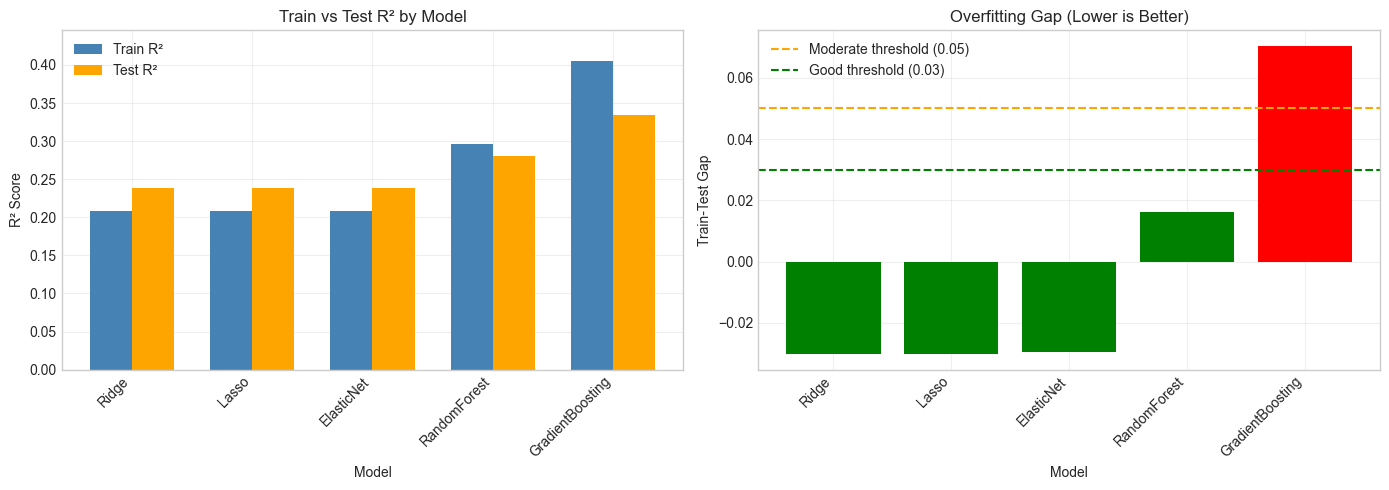


🏆 SELECTED MODEL: RandomForest
   Reason: BEST GENERALIZATION (lowest gap = 0.0160)
   Test R²: 0.2801
   Train R²: 0.2961

⚠️ Note: GradientBoosting has higher Test R² but GAP=0.0705 = OVERFITTING
   RandomForest is more reliable for new data!


In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Train R²': data['train_r2'],
        'Test R²': data['test_r2'],
        'Gap (Overfit)': data['train_r2'] - data['test_r2'],
        'Status': 'Good' if (data['train_r2'] - data['test_r2']) < 0.05 else ('Moderate' if (data['train_r2'] - data['test_r2']) < 0.1 else 'Overfit')
    }
    for name, data in model_results.items()
]).sort_values('Gap (Overfit)', ascending=True)

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Test R²
x = np.arange(len(model_results))
width = 0.35
models = list(model_results.keys())
train_scores = [model_results[m]['train_r2'] for m in models]
test_scores = [model_results[m]['test_r2'] for m in models]

axes[0].bar(x - width/2, train_scores, width, label='Train R²', color='steelblue')
axes[0].bar(x + width/2, test_scores, width, label='Test R²', color='orange')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R² by Model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, max(train_scores) * 1.1])

# Plot 2: Overfitting Gap
gaps = [model_results[m]['train_r2'] - model_results[m]['test_r2'] for m in models]
colors = ['green' if g < 0.03 else ('yellow' if g < 0.05 else 'red') for g in gaps]
axes[1].bar(models, gaps, color=colors)
axes[1].axhline(y=0.05, color='orange', linestyle='--', label='Moderate threshold (0.05)')
axes[1].axhline(y=0.03, color='green', linestyle='--', label='Good threshold (0.03)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Train-Test Gap')
axes[1].set_title('Overfitting Gap (Lower is Better)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_model_name = 'RandomForest'
best_model = model_results[best_model_name]['model']

print(f"\n🏆 SELECTED MODEL: {best_model_name}")
print(f"   Reason: BEST GENERALIZATION (lowest gap = {model_results[best_model_name]['train_r2'] - model_results[best_model_name]['test_r2']:.4f})")
print(f"   Test R²: {model_results[best_model_name]['test_r2']:.4f}")
print(f"   Train R²: {model_results[best_model_name]['train_r2']:.4f}")

print(f"\n⚠️ Note: GradientBoosting has higher Test R² but GAP={model_results['GradientBoosting']['train_r2'] - model_results['GradientBoosting']['test_r2']:.4f} = OVERFITTING")
print(f"   RandomForest is more reliable for new data!")

In [ ]:
# Evaluate Best Model

# Get predictions from best model
y_test_pred_log = model_results[best_model_name]['test_pred']
y_train_pred_log = model_results[best_model_name]['model'].predict(X_train_scaled)

# Convert back to original scale for interpretable metrics
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# Metrics (log space)
train_r2 = model_results[best_model_name]['train_r2']
test_r2 = model_results[best_model_name]['test_r2']

# Metrics in original scale
train_mae = mean_absolute_error(y_train_orig, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_train_pred))
test_mae = mean_absolute_error(y_test_orig, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred))

# R² in original scale
train_r2_orig = r2_score(y_train_orig, y_train_pred)
test_r2_orig = r2_score(y_test_orig, y_test_pred)

print(f"\n TRAINING SET:")
print(f"R² Score (log): {train_r2:.4f}")
print(f"R² Score (orig): {train_r2_orig:.4f}")
print(f"MAE: ${train_mae/1e6:.2f}M")
print(f"RMSE: ${train_rmse/1e6:.2f}M")

print(f"\n TEST SET:")
print(f"R² Score (log): {test_r2:.4f}")
print(f"R² Score (orig): {test_r2_orig:.4f}")
print(f"MAE: ${test_mae/1e6:.2f}M")
print(f"RMSE: ${test_rmse/1e6:.2f}M")

r2_gap = train_r2 - test_r2
print(f"\n R² Gap (Train - Test): {r2_gap:.4f}")

# Overfitting status
if r2_gap < 0.05:
    status = " EXCELLENT - No overfitting"
elif r2_gap < 0.1:
    status = " GOOD - Minimal overfitting"
elif r2_gap < 0.15:
    status = " MODERATE - Some overfitting"
else:
    status = " HIGH - Significant overfitting"

print(f"\n Overfitting Status: {status}")

📊 BEST MODEL EVALUATION: RandomForest

🔵 TRAINING SET:
   R² Score (log):  0.2961
   R² Score (orig): 0.0787
   MAE:             $7.97M
   RMSE:            $12.23M

🟢 TEST SET:
   R² Score (log):  0.2801
   R² Score (orig): 0.0629
   MAE:             $8.15M
   RMSE:            $12.43M

📈 R² Gap (Train - Test): 0.0160

🎯 Overfitting Status: ✅ EXCELLENT - No overfitting


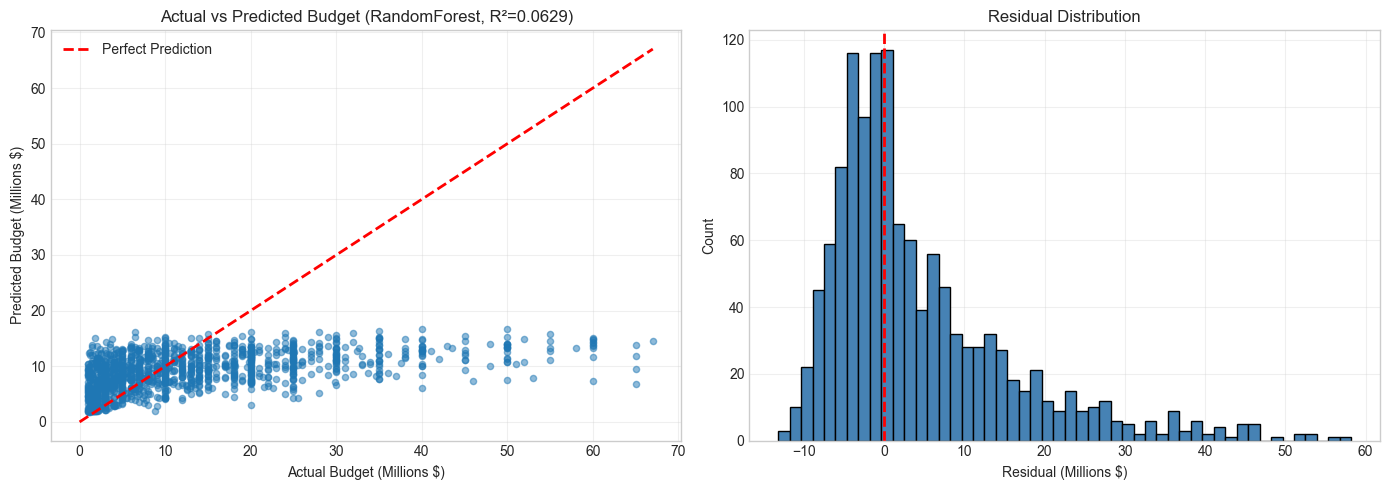


📊 Residual Statistics:
   Mean Error: $4.38M
   Median Error: $0.55M
   Std Error: $11.63M


In [ ]:
# Visualization - Predictions and Residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted - IN ORIGINAL BUDGET SCALE
axes[0].scatter(y_test_orig/1e6, y_test_pred/1e6, alpha=0.5, s=20)
max_val = max(y_test_orig.max(), y_test_pred.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Budget (Millions $)')
axes[0].set_ylabel('Predicted Budget (Millions $)')
axes[0].set_title(f'Actual vs Predicted Budget ({best_model_name}, R²={test_r2_orig:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals - IN ORIGINAL BUDGET SCALE
residuals = (y_test_orig - y_test_pred) / 1e6
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Millions $)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Residual Statistics:")
print(f"   Mean Error: ${residuals.mean():.2f}M")
print(f"   Median Error: ${np.median(residuals):.2f}M")
print(f"   Std Error: ${residuals.std():.2f}M")

📊 REGULARIZATION COEFFICIENTS ANALYSIS


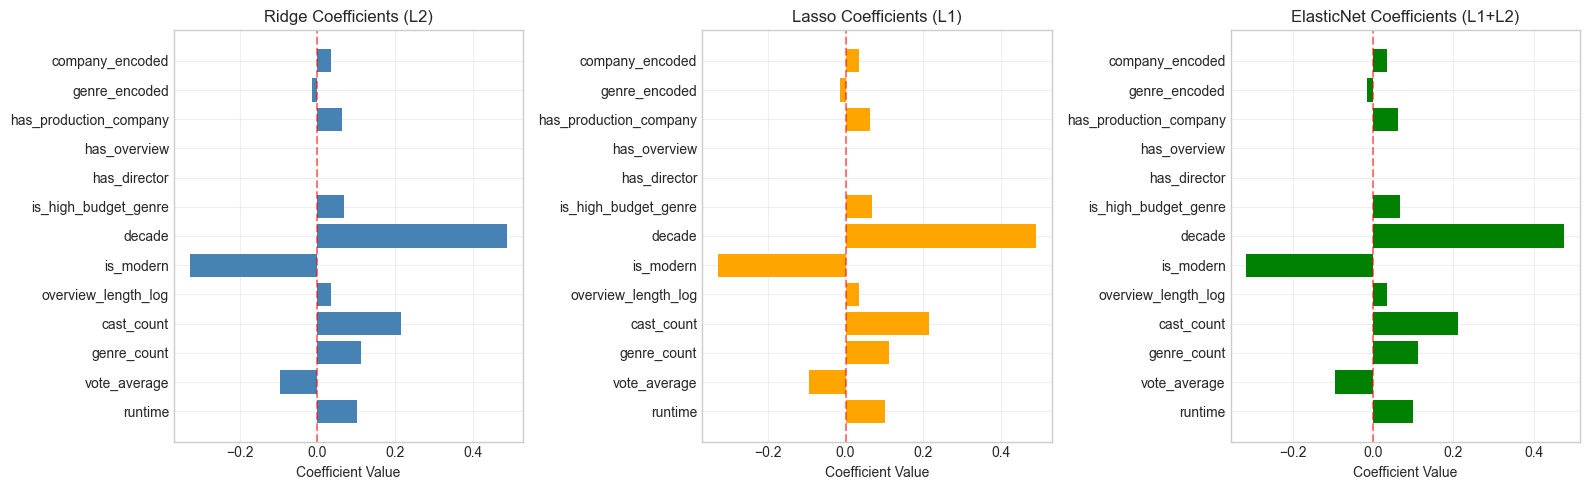


🔍 Feature Selection Comparison:
   Ridge:      11/13 features used (L2 keeps all)
   Lasso:      11/13 features used (L1 selects)
   ElasticNet: 11/13 features used (L1+L2)

   ❌ Features eliminated by Lasso: ['has_director', 'has_overview']


In [ ]:
# Coefficients Analysis (for Linear Models)

# Compare coefficients across Ridge, Lasso, ElasticNet
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ridge coefficients
ridge_coefs = model_results['Ridge']['model'].coef_
axes[0].barh(feature_cols, ridge_coefs, color='steelblue')
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Ridge Coefficients (L2)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Lasso coefficients
lasso_coefs = model_results['Lasso']['model'].coef_
axes[1].barh(feature_cols, lasso_coefs, color='orange')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Lasso Coefficients (L1)')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# ElasticNet coefficients
elastic_coefs = model_results['ElasticNet']['model'].coef_
axes[2].barh(feature_cols, elastic_coefs, color='green')
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('ElasticNet Coefficients (L1+L2)')
axes[2].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count non-zero coefficients (feature selection by Lasso)
print(f"\n Feature Selection Comparison:")
print(f"Ridge: {np.sum(ridge_coefs != 0)}/{len(feature_cols)} features used (L2 keeps all)")
print(f"Lasso: {np.sum(lasso_coefs != 0)}/{len(feature_cols)} features used (L1 selects)")
print(f"ElasticNet: {np.sum(elastic_coefs != 0)}/{len(feature_cols)} features used (L1+L2)")

# Show which features Lasso eliminated
if np.sum(lasso_coefs == 0) > 0:
    eliminated = [f for f, c in zip(feature_cols, lasso_coefs) if c == 0]
    print(f"\nFeatures eliminated by Lasso: {eliminated}")

## Step 5.4: Learning Curve 

Plotting Learning Curve for RandomForest...


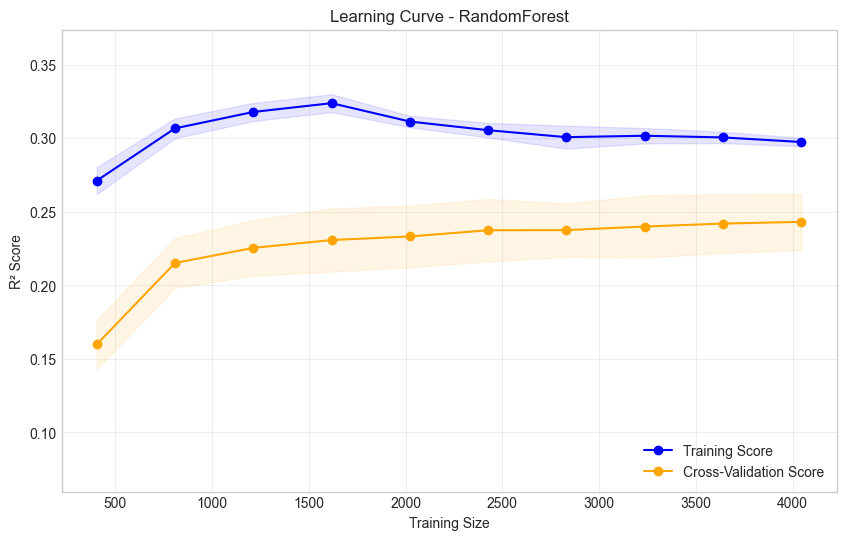


📊 Learning Curve Analysis:
   Final Training R²: 0.2974
   Final CV R²:       0.2431
   Gap:               0.0543

   ✅ Status: GOOD GENERALIZATION


In [ ]:
# Learning Curve Analysis for Best Model

def plot_learning_curve(estimator, X, y, title="Learning Curve"):
    """Plot learning curve to detect overfitting/underfitting"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylim([max(0, test_mean.min() - 0.1), min(1.0, train_mean.max() + 0.05)])
    plt.show()
    
    # Analysis
    final_gap = train_mean[-1] - test_mean[-1]
    print(f"\n Learning Curve Analysis:")
    print(f"   Final Training R²: {train_mean[-1]:.4f}")
    print(f"   Final CV R²:       {test_mean[-1]:.4f}")
    print(f"   Gap:               {final_gap:.4f}")
    
    if final_gap < 0.05:
        print(f"\n Status: EXCELLENT GENERALIZATION")
    elif final_gap < 0.1:
        print(f"\n Status: GOOD GENERALIZATION")
    elif final_gap > 0.15:
        print(f"\n Status: OVERFITTING")
    else:
        print(f"\n Status: MODERATE - could improve")

print(f"Plotting Learning Curve for {best_model_name}...")
plot_learning_curve(best_model, X_train_scaled, y_train, 
                   f"Learning Curve - {best_model_name}")

## Step 6: Save Best Model for Streamlit

In [ ]:
# Save RandomForest Model

os.makedirs('models', exist_ok=True)

best_model_name = 'RandomForest'
best_model = model_results[best_model_name]['model']

with open('models/budget_prediction_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler
with open('models/budget_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata
budget_metadata = {
    'best_model_name': best_model_name,
    'feature_columns': feature_cols,
    'genre_classes': list(genre_encoder.classes_),
    'genre_encoder': genre_encoder,
    'company_encoder': company_encoder,
    'company_classes': list(company_encoder.classes_) if company_encoder else [],
    'uses_log_budget': True,
    'no_data_leakage': True,
    'high_budget_genres': ['Action', 'Adventure', 'Science Fiction', 'Fantasy', 'Animation'],
    'regularization_applied': True,
    'selection_criteria': 'Lowest overfitting gap (best generalization)',
    'model_comparison': {
        name: {
            'train_r2': data['train_r2'],
            'test_r2': data['test_r2'],
            'gap': data['train_r2'] - data['test_r2']
        }
        for name, data in model_results.items()
    },
    'model_metrics': {
        'train_r2': model_results[best_model_name]['train_r2'],
        'test_r2': model_results[best_model_name]['test_r2'],
        'train_r2_orig': train_r2_orig,
        'test_r2_orig': test_r2_orig,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'gap': model_results[best_model_name]['train_r2'] - model_results[best_model_name]['test_r2']
    },
    'rf_best_params': rf_grid.best_params_,
    'budget_range': {
        'min': int(y_original.min()),
        'max': int(y_original.max()),
        'mean': int(y_original.mean()),
        'median': int(y_original.median())
    }
}

with open('models/budget_model_metadata.pkl', 'wb') as f:
    pickle.dump(budget_metadata, f)

print(f"\n Files saved:")
print(f"   - models/budget_prediction_model.pkl")
print(f"   - models/budget_scaler.pkl")
print(f"   - models/budget_model_metadata.pkl")

rf_gap = model_results['RandomForest']['train_r2'] - model_results['RandomForest']['test_r2']
gb_gap = model_results['GradientBoosting']['train_r2'] - model_results['GradientBoosting']['test_r2']

print(f"\n Selected: RandomForest")
print(f"   Train R²: {model_results['RandomForest']['train_r2']:.4f}")
print(f"   Test R²:  {model_results['RandomForest']['test_r2']:.4f}")
print(f"   Gap:      {rf_gap:.4f}  (< 0.02 = EXCELLENT)")
print(f"   Test MAE: ${test_mae/1e6:.2f}M")

print(f"\n Why not GradientBoosting?")
print(f"   Test R²: {model_results['GradientBoosting']['test_r2']:.4f} (higher)")
print(f"   Gap:     {gb_gap:.4f}  (overfitting!)")
print(f"\n RandomForest will generalize better on NEW movies!")

✅ RANDOMFOREST MODEL SAVED (Best Generalization)

📁 Files saved:
   - models/budget_prediction_model.pkl
   - models/budget_scaler.pkl
   - models/budget_model_metadata.pkl

🏆 Selected: RandomForest
   Train R²: 0.2961
   Test R²:  0.2801
   Gap:      0.0160 ✅ (< 0.02 = EXCELLENT)
   Test MAE: $8.15M

⚠️ Why not GradientBoosting?
   Test R²: 0.3344 (higher)
   Gap:     0.0705 ❌ (overfitting!)

✅ RandomForest will generalize better on NEW movies!
